## IMPORTS

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sentencepiece as spm

import os
import math
import time
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tqdm.auto import tqdm as tqdm_auto
from tqdm import tqdm as tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

from torchinfo import summary
from torchview import draw_graph
import graphviz as gv

## SEED

In [91]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## DEVICE SETUP

In [92]:
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")
USE_AMP = USE_CUDA

if USE_CUDA:
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

print(f"Device: {DEVICE}")
print(f"AMP enabled: {USE_AMP}")

if USE_CUDA:
    print(f"CUDA is available. Training will run on GPU.")
else:
    print("CUDA is not available in this kernel. Training will run on CPU and be very slow.")

Device: cuda
AMP enabled: True
CUDA is available. Training will run on GPU.


## PATHS

In [93]:
root = Path.cwd()
data_dir = root / 'Data'
corpus_dir = data_dir / 'hindi_corpus' / 'train'
cls_csv = data_dir / 'text_classification_dataset' / 'train.csv'

out_dir = root / 'outputs'
(out_dir / "checkpoints").mkdir(parents=True, exist_ok=True)
(out_dir / "generations").mkdir(parents=True, exist_ok=True)
(out_dir / "predictions").mkdir(parents=True, exist_ok=True)
(out_dir / "tokenizer").mkdir(parents=True, exist_ok=True)
(out_dir / "splits").mkdir(parents=True, exist_ok=True)

print(f"Root Directory        : {root}")
print(f"Data Directory        : {data_dir}")
print(f"Corpus Directory      : {corpus_dir}")
print(f"Classification CSV    : {cls_csv}")
print(f"Output Directory      : {out_dir}")
print(f"Checkpoints Directory : {out_dir / 'checkpoints'}")
print(f"Generations Directory : {out_dir / 'generations'}")
print(f"Predictions Directory : {out_dir / 'predictions'}")
print(f"Tokenizer Directory   : {out_dir / 'tokenizer'}")
print(f"Splits Directory      : {out_dir / 'splits'}")

Root Directory        : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3
Data Directory        : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\Data
Corpus Directory      : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\Data\hindi_corpus\train
Classification CSV    : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\Data\text_classification_dataset\train.csv
Output Directory      : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs
Checkpoints Directory : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\checkpoints
Generations Directory : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\generations
Predictions Directory : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\predictions
Tokenizer Directory   : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\tokenizer
Splits Directory      : f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\splits


## PARAMS

In [94]:
VOCAB_SIZE = 5000
BLOCK_SIZE = 192

N_LAYER: int = 6
N_HEAD: int = 6
N_EMBED: int = 384
DROPOUT: float = 0.1

LM_BATCH_SIZE: int = 32
LM_EPOCHS: int = 20
LM_LEARNING_RATE: float = 3e-4
LM_WARMUP_STEPS: int = 300
LM_WEIGHT_DECAY: float = 0.1
LM_LABEL_SMOOTHING: float = 0.1
GRAD_CLIP: float = 1.0

LM_MAX_TRAIN_STEPS_PER_EPOCH: int | None = 20000
LM_MAX_VAL_STEPS_PER_EPOCH: int | None = 2000

CLS_BATCH_SIZE: int = 32
CLS_EPOCHS: int = 12
CLS_LEARNING_RATE: float = 3e-5
CLS_BACKBONE_LEARNING_RATE_MULTIPLIER: float = 0.2
CLS_WEIGHT_DECAY: float = 0.05
EARLY_STOPPING_PATIENCE: int = 3

VALIDATION_RATIO_LM: float = 0.1
VALIDATION_RATIO_CLS: float = 0.2

## CORPUS PROCESSING

In [95]:
rows = []

for file in tqdm(sorted(corpus_dir.glob('*.txt')), desc="Reading Corpus "):
    try:
        txt = file.read_text(encoding='utf-8', errors='ignore').strip()
        if txt:
            rows.append({'filename': file.name.split('.')[0], 'text': txt})
    except Exception as e:
        continue
    
rows[:5]

Reading Corpus : 100%|██████████| 44000/44000 [00:02<00:00, 15288.61it/s]


[{'filename': '0',
  'text': 'चैनल एस एक बांग्ला टीवी चैनल है। यह एक मनोरंजन चैनल है।'},
 {'filename': '1',
  'text': 'ज़ागान, पश्चिमी पोलैंड में एक शहर है। यह शहर बोबर नदी के किनारे स्थित है। 2004 के जनगणना के अनुसार यहाँ की आबादी 26665 है। यह शहर ज़ागान प्रदेश की राजधानी है।\nअडोल्फ़ एन्ग्लेर रेंहोल्ड रोएहृच्त वोल्फगांग सामुएल लुकस्ज़ गर्गुलअ \n दुन्स, स्कॉटलैंड नेत्फेन, जर्मनी ओरत्रंद, जर्मनी तेल्तो, जर्मनी'},
 {'filename': '10',
  'text': 'अभिनव कदम हिन्दी की एक साहित्यिक पत्रिका है। \n अक्षय जीवन · अक्षर पर्व · अक्षय जीवन · अखंड ज्योति · अनंत अविराम · अपरिहार्य · अभिनव कदम · अभिनव बालमन · अभिव्यक्ति · अर्गला · अहा जिंदगी · आकल्प · आज तक · आईबीएन खबर · आई.सी.एम.आर. · आलोचना · आविष्कार · इन.कॉम · इलेक्ट्रॉनिकी आपके लिए · उर्वशी · एनडीटीवी खबर · ओशो टाइम्स · कथाक्रम · कथादेश · कथाबिम्\u200dब · कल्याण · कालदीर्घा · कुरुक्षेत्र · खनन भारती · गद्य कोश · गीत-पहल · गूगल समाचार · गृहलक्ष्\u200dमी · चकमक · चन्दामामा · चंपक  · चित्रलेखा · जनोक्ति · जल चेतना · जानकी पुल · ड्रीम 2047 · तद्भव ·

In [96]:
ids = [row['filename'] for row in rows]
train_ids , val_ids = train_test_split(ids, test_size=VALIDATION_RATIO_LM, random_state=SEED)
train_ids = set(train_ids)
val_ids = set(val_ids)

In [97]:
train_texts = [row['text'] for row in rows if row['filename'] in train_ids]
val_texts = [row['text'] for row in rows if row['filename'] in val_ids]

In [98]:
(out_dir / 'splits' / 'lm_train_texts.txt').write_text('\n'.join(train_texts), encoding='utf-8')
(out_dir / 'splits' / 'lm_val_texts.txt').write_text('\n'.join(val_texts), encoding='utf-8')

print(f"Total Texts       : {len(rows)}")
print(f"Training Texts    : {len(train_texts)}")
print(f"Validation Texts  : {len(val_texts)}")
print(f"Overlapping Texts : {len(train_ids.intersection(val_ids))}")

Total Texts       : 43331
Training Texts    : 38997
Validation Texts  : 4334
Overlapping Texts : 0


## SentencePiece TOKENIZER

In [99]:
# hindi words tokenization
hindi_token_file = out_dir / 'tokenizer' / 'sp_train_text.txt'
hindi_token_file.write_text('\n'.join(train_texts), encoding='utf-8')

spm_prefix = out_dir / 'tokenizer' / 'hindi_spm_bpe'
spm_model = spm_prefix.with_suffix('.model')

if not spm_model.exists():
    spm.SentencePieceTrainer.train(
        input=str(hindi_token_file),
        model_prefix=str(spm_prefix),
        vocab_size=VOCAB_SIZE,
        model_type='bpe',
        character_coverage=0.9995,
        # max_sentence_length=10000,
        split_digits=False,
        unk_id=0,
        bos_id=1,
        eos_id=2,
        pad_id=3,
    )

spm_processor = spm.SentencePieceProcessor(model_file=str(spm_model))

print(f"Tokenizer Vocabulary Size          : {spm_processor.vocab_size()}")
print(f"Tokenizer Pad ID                   : {spm_processor.pad_id()}")
print(f"Tokenizer Unknown ID               : {spm_processor.unk_id()}")
print(f"Tokenizer Beginning of Sentence ID : {spm_processor.bos_id()}")
print(f"Tokenizer End of Sentence ID       : {spm_processor.eos_id()}")
print(f"Tokenizer Sample Encoding          : {spm_processor.encode(train_texts[0][:100], out_type=int)[:20]}")
# print(f"Tokenizer Sample Encoding : {spm_processor.encode('यह एक परीक्षण वाक्य है।', out_type=str)})")

Tokenizer Vocabulary Size          : 5000
Tokenizer Pad ID                   : 3
Tokenizer Unknown ID               : 0
Tokenizer Beginning of Sentence ID : 1
Tokenizer End of Sentence ID       : 2
Tokenizer Sample Encoding          : [4203, 1499, 58, 2112, 1573, 3716, 4203, 11, 4875, 83, 58, 3887, 2569, 4203, 11, 4875]


## DATA PROCESSING

In [100]:
class_df = pd.read_csv(cls_csv)
print(f"Columns : {list(class_df.columns)}, Row : {len(class_df)}")
class_df = class_df.dropna().copy()

if class_df['experience'].dtype == object:
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    class_df['label_id'] = class_df['experience'].astype(str).str.strip().str.lower().map(label_map)
else:
    class_df['label_id'] = class_df['experience'].astype(int)
    
class_df = class_df.dropna(subset=['label_id']).copy()
class_df['label_id'] = class_df['label_id'].astype(int)

class_train_df, class_val_df = train_test_split(class_df, test_size=VALIDATION_RATIO_CLS, random_state=SEED, stratify=class_df['label_id'])

print("Training set shape:", class_train_df.shape)
print("Validation set shape:", class_val_df.shape)
print("\nTraining set label counts:")
print(class_train_df['label_id'].value_counts().to_string())
print("\nValidation set label counts:")
print(class_val_df['label_id'].value_counts().to_string())

Columns : ['text', 'experience'], Row : 718
Training set shape: (574, 3)
Validation set shape: (144, 3)

Training set label counts:
label_id
2    218
0    192
1    164

Validation set label counts:
label_id
2    55
0    48
1    41


## DATASET && DATALOADER PROCESSING

In [101]:
class LanguageModelingDataset(Dataset):
    def __init__(self, texts: List[str], block_size: int, eos_id: int):
        self.block_size = block_size
        token_lines = []
        
        for i in texts:
            token_lines.extend(spm_processor.encode(i, out_type=int))
            token_lines.append(eos_id)
        
        self.tokens = torch.tensor(token_lines, dtype=torch.long)
    
    def __len__(self):
        return max(0, len(self.tokens) - self.block_size - 1)
    
    def __getitem__(self, index):
        x = self.tokens[index : index + self.block_size]
        y = self.tokens[index + 1 : index + self.block_size + 1]
        return x, y
    
class TextClassificationDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, text_col: str, max_len: int, pad_id: int):
        self.texts = frame[text_col].tolist()
        self.labels = frame['label_id'].tolist()
        self.max_len = max_len
        self.pad_id = pad_id
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, index):
        ids = spm_processor.encode(self.texts[index], out_type=int)[: self.max_len]
        if len(ids) < self.max_len:
            ids = ids + [self.pad_id] * (self.max_len - len(ids))
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[index], dtype=torch.long)


lm_train_dataset = LanguageModelingDataset(train_texts, block_size=BLOCK_SIZE, eos_id=spm_processor.eos_id())
lm_val_dataset = LanguageModelingDataset(val_texts, block_size=BLOCK_SIZE, eos_id=spm_processor.eos_id())

cls_train_dataset = TextClassificationDataset(class_train_df, text_col='text', max_len=BLOCK_SIZE, pad_id=spm_processor.pad_id())
cls_val_dataset = TextClassificationDataset(class_val_df, text_col='text', max_len=BLOCK_SIZE, pad_id=spm_processor.pad_id())

# Windows + notebooks + very large TensorDataset can crash with multiprocessing workers.
if DEVICE.type == "cuda":
    LM_NUM_WORKERS = 0 if os.name == "nt" else min(4, os.cpu_count() or 1)
    CLS_NUM_WORKERS = 0 if os.name == "nt" else min(2, os.cpu_count() or 1)
else:
    LM_NUM_WORKERS = 0
    CLS_NUM_WORKERS = 0

PIN_MEMORY = DEVICE.type == "cuda"

lm_loader_kwargs = {
    "num_workers": LM_NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}
if LM_NUM_WORKERS > 0:
    lm_loader_kwargs.update({
        "persistent_workers": True,
        "prefetch_factor": 2,
    })

cls_loader_kwargs = {
    "num_workers": CLS_NUM_WORKERS,
    "pin_memory": PIN_MEMORY,
}
if CLS_NUM_WORKERS > 0:
    cls_loader_kwargs.update({
        "persistent_workers": True,
        "prefetch_factor": 2,
    })

lm_train_dataloader = DataLoader(lm_train_dataset, batch_size=LM_BATCH_SIZE, shuffle=True, drop_last=True, **lm_loader_kwargs)
lm_val_dataloader = DataLoader(lm_val_dataset, batch_size=LM_BATCH_SIZE, shuffle=False, drop_last=True, **lm_loader_kwargs)

cls_train_dataloader = DataLoader(cls_train_dataset, batch_size=CLS_BATCH_SIZE, shuffle=True, **cls_loader_kwargs)
cls_val_dataloader = DataLoader(cls_val_dataset, batch_size=CLS_BATCH_SIZE, shuffle=False, **cls_loader_kwargs)

print(f"Language Modeling\n- Training Batches   : {len(lm_train_dataloader)}\n- Validation Batches : {len(lm_val_dataloader)}")
print(f"\nText Classification\n- Training Batches   : {len(cls_train_dataloader)}\n- Validation Batches : {len(cls_val_dataloader)}")
print(f"\nLoader setup\n- LM workers: {LM_NUM_WORKERS}\n- CLS workers: {CLS_NUM_WORKERS}\n- pin_memory: {PIN_MEMORY}")

Language Modeling
- Training Batches   : 589908
- Validation Batches : 70460

Text Classification
- Training Batches   : 18
- Validation Batches : 5

Loader setup
- LM workers: 0
- CLS workers: 0
- pin_memory: True


## MODEL

In [102]:
class MiniGPT(nn.Module):
    def __init__(self, vocab_size: int, block_size: int, n_layer: int, n_head: int, n_embd: int, dropout: float):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, n_embd)
        self.position_embedding = nn.Embedding(block_size, n_embd)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=n_embd,
            nhead=n_head,
            dim_feedforward=4 * n_embd,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layer,
            norm=nn.LayerNorm(n_embd),
            enable_nested_tensor=False,
        )

    def _causal_mask(self, T: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
        mask = torch.full((T, T), float("-inf"), device=device, dtype=dtype)
        return torch.triu(mask, diagonal=1)

    def forward(self, x):
        _, T = x.shape
        if T > self.block_size:
            raise ValueError(f"Input sequence length {T} exceeds block size {self.block_size}")

        pos = torch.arange(0, T, device=x.device)
        h = self.token_embedding(x) + self.position_embedding(pos)[None, :, :]
        h = self.dropout(h)

        attention_mask = self._causal_mask(T, device=h.device, dtype=h.dtype)
        h = self.transformer(h, mask=attention_mask)
        return h


class GPTLanguageModel(nn.Module):
    def __init__(self, backbone: MiniGPT, vocab_size: int):
        super().__init__()
        self.backbone = backbone
        self.lm_head = nn.Linear(backbone.token_embedding.embedding_dim, vocab_size, bias=False)
        self.lm_head.weight = self.backbone.token_embedding.weight

    def forward(self, x, targets=None, label_smoothing=0.0):
        h = self.backbone(x)
        logits = self.lm_head(h)
        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = nn.functional.cross_entropy(
                logits.reshape(B * T, V),
                targets.reshape(B * T),
                label_smoothing=label_smoothing,
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, x, max_new_tokens=50, temperature=0.9, top_k=40):
        self.eval()

        for _ in range(max_new_tokens):
            x_cond = x[:, -self.backbone.block_size :]
            logits, _ = self.forward(x_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-6)

            if top_k is not None and top_k > 0:
                k = min(top_k, logits.size(-1))
                values, _ = torch.topk(logits, k=k)
                logits[logits < values[:, [-1]]] = float("-inf")

            probs = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            x = torch.cat([x, next_token], dim=1)

        return x


class GPTTextClassifier(nn.Module):
    def __init__(self, backbone: MiniGPT, pad_id: int, num_classes: int = 3):
        super().__init__()
        self.backbone = backbone
        self.pad_id = pad_id
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(backbone.token_embedding.embedding_dim, num_classes)

    def forward(self, x, targets=None):
        h = self.backbone(x)
        valid_mask = (x != self.pad_id).long()
        last_pos = (valid_mask.sum(dim=1) - 1).clamp(min=0)
        last_tok = h[torch.arange(h.size(0), device=h.device), last_pos]
        logits = self.fc(self.dropout(last_tok))
        loss = None

        if targets is not None:
            loss = nn.functional.cross_entropy(logits, targets)

        return logits, loss

In [103]:
backbone = MiniGPT(
    vocab_size=spm_processor.vocab_size(),
    block_size=BLOCK_SIZE,
    n_layer=N_LAYER,
    n_head=N_HEAD,
    n_embd=N_EMBED,
    dropout=DROPOUT,
).to(DEVICE)

lm_model = GPTLanguageModel(backbone, vocab_size=spm_processor.vocab_size()).to(DEVICE)

lm_optimizer = GPTLanguageModel(backbone=backbone, vocab_size=spm_processor.vocab_size()).to(DEVICE)

lm_optimizer = torch.optim.AdamW(
    lm_model.parameters(),
    lr=LM_LEARNING_RATE,
    betas=(0.9, 0.95),
    weight_decay=LM_WEIGHT_DECAY,
)

steps_per_epoch_raw = max(1, len(lm_train_dataloader))
steps_per_epoch = min(steps_per_epoch_raw, LM_MAX_TRAIN_STEPS_PER_EPOCH) if LM_MAX_TRAIN_STEPS_PER_EPOCH is not None else steps_per_epoch_raw
totals_steps = LM_EPOCHS * steps_per_epoch

lr_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    lm_optimizer,
    max_lr=LM_LEARNING_RATE,
    total_steps=totals_steps,
    pct_start=min(0.3, LM_WARMUP_STEPS / max(1, totals_steps)),
    anneal_strategy='cos',
)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

print(f"LM scheduler steps/epoch: {steps_per_epoch} (raw: {steps_per_epoch_raw})")
print(f"LM scheduler total steps: {totals_steps}")

LM scheduler steps/epoch: 20000 (raw: 589908)
LM scheduler total steps: 400000


## LM MODEL SUMMARY

In [104]:
dummy_tokens = torch.zeros(2, 50, dtype=torch.long, device=DEVICE)

summary_1 = summary(
    backbone,
    input_data=dummy_tokens,
    dtypes=[torch.long],
    verbose=0,
    device=DEVICE,
)

summary_2 = summary(
        lm_model,
        input_data=dummy_tokens,
        dtypes=[torch.long],
        verbose=0,
        device=DEVICE,
)

In [105]:
print("\nBackbone Model Summary : ")
summary_1


Backbone Model Summary : 


Layer (type:depth-idx)                        Output Shape              Param #
MiniGPT                                       [2, 50, 384]              --
├─Embedding: 1-1                              [2, 50, 384]              1,920,000
├─Embedding: 1-2                              [50, 384]                 73,728
├─Dropout: 1-3                                [2, 50, 384]              --
├─TransformerEncoder: 1-4                     [2, 50, 384]              --
│    └─ModuleList: 2-1                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [2, 50, 384]              1,774,464
│    │    └─TransformerEncoderLayer: 3-2      [2, 50, 384]              1,774,464
│    │    └─TransformerEncoderLayer: 3-3      [2, 50, 384]              1,774,464
│    │    └─TransformerEncoderLayer: 3-4      [2, 50, 384]              1,774,464
│    │    └─TransformerEncoderLayer: 3-5      [2, 50, 384]              1,774,464
│    │    └─TransformerEncoderLayer: 3-6      [2,

In [106]:
print("\n\nLM Model Summary : ")
summary_2



LM Model Summary : 


Layer (type:depth-idx)                             Output Shape              Param #
GPTLanguageModel                                   [2, 50, 5000]             --
├─MiniGPT: 1-1                                     [2, 50, 384]              --
│    └─Embedding: 2-1                              [2, 50, 384]              1,920,000
│    └─Embedding: 2-2                              [50, 384]                 73,728
│    └─Dropout: 2-3                                [2, 50, 384]              --
│    └─TransformerEncoder: 2-4                     [2, 50, 384]              --
│    │    └─ModuleList: 3-1                        --                        10,646,784
│    │    └─LayerNorm: 3-2                         [2, 50, 384]              768
├─Linear: 1-2                                      [2, 50, 5000]             1,920,000
Total params: 14,561,280
Trainable params: 14,561,280
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 25.57
Input size (MB): 0.00
Forward/backward pass size 

In [107]:
os.makedirs("./outputs/Architecture", exist_ok=True)

dummy_tokens = torch.zeros(2, 50, dtype=torch.long, device=DEVICE)

model_graph = draw_graph(
        model=backbone,
        input_data=dummy_tokens,
        graph_name=backbone.__class__.__name__,
        expand_nested=True,
        save_graph=True,
        depth=10,
        directory="./outputs/Architecture"
    )

gv.render(engine='dot', format='svg', filepath=f'./outputs/Architecture/{backbone.__class__.__name__}.gv')
gv.render(engine='dot', format='pdf', filepath=f'./outputs/Architecture/{backbone.__class__.__name__}.gv')

'outputs\\Architecture\\MiniGPT.gv.pdf'

In [108]:
model_graph = draw_graph(
        model=lm_model,
        input_data=dummy_tokens,
        graph_name=lm_model.__class__.__name__,
        expand_nested=True,
        save_graph=True,
        depth=10,
        directory="./outputs/Architecture"
    )

gv.render(engine='dot', format='svg', filepath=f'./outputs/Architecture/{lm_model.__class__.__name__}.gv')
gv.render(engine='dot', format='pdf', filepath=f'./outputs/Architecture/{lm_model.__class__.__name__}.gv')

'outputs\\Architecture\\GPTLanguageModel.gv.pdf'

In [20]:
num_lm_epochs = LM_EPOCHS
lm_train_losses = np.zeros(num_lm_epochs)
lm_val_losses = np.zeros(num_lm_epochs)
lm_train_ppls = np.zeros(num_lm_epochs)
lm_val_ppls = np.zeros(num_lm_epochs)

# Reset scaler state on each notebook run to avoid stale optimizer-stage errors.
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
PIN_MEMORY = DEVICE.type == "cuda"

best_ppl = float("inf")
actual_lm_epochs = 0
lm_log = []
best_lm_path = out_dir / "checkpoints" / "lm_best.pt"
os.makedirs(best_lm_path.parent, exist_ok=True)

train_steps_limit = min(len(lm_train_dataloader), LM_MAX_TRAIN_STEPS_PER_EPOCH) if LM_MAX_TRAIN_STEPS_PER_EPOCH is not None else len(lm_train_dataloader)
val_steps_limit = min(len(lm_val_dataloader), LM_MAX_VAL_STEPS_PER_EPOCH) if LM_MAX_VAL_STEPS_PER_EPOCH is not None else len(lm_val_dataloader)
total_len = train_steps_limit + val_steps_limit

print(f"LM step limits -> train: {train_steps_limit}, val: {val_steps_limit}")

for epoch in range(num_lm_epochs):
    epoch_str = str(epoch + 1).rjust(len(str(num_lm_epochs)), " ")

    with tqdm(total=total_len, desc=f"LM Epoch [ {epoch_str}/{num_lm_epochs} ] : ") as pbar:
        lm_model.train()
        train_loss_list = []

        for step_idx, (x, y) in enumerate(lm_train_dataloader):
            if step_idx >= train_steps_limit:
                break

            x = x.to(DEVICE, non_blocking=PIN_MEMORY)
            y = y.to(DEVICE, non_blocking=PIN_MEMORY)
            lm_optimizer.zero_grad(set_to_none=True)

            if USE_AMP:
                with torch.amp.autocast("cuda", enabled=True):
                    _, loss = lm_model(x, y, label_smoothing=LM_LABEL_SMOOTHING)

                scaler.scale(loss).backward()
                scaler.unscale_(lm_optimizer)
                torch.nn.utils.clip_grad_norm_(lm_model.parameters(), GRAD_CLIP)
                scaler.step(lm_optimizer)
                scaler.update()
            else:
                _, loss = lm_model(x, y, label_smoothing=LM_LABEL_SMOOTHING)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(lm_model.parameters(), GRAD_CLIP)
                lm_optimizer.step()

            lr_scheduler.step()

            train_loss_list.append(loss.item())
            pbar.update(1)

        train_loss = float(np.mean(train_loss_list)) if train_loss_list else float("inf")
        train_ppl = math.exp(train_loss) if train_loss < 20 else float("inf")

        lm_model.eval()
        val_loss_list = []
        with torch.no_grad():
            for step_idx, (x, y) in enumerate(lm_val_dataloader):
                if step_idx >= val_steps_limit:
                    break

                x = x.to(DEVICE, non_blocking=PIN_MEMORY)
                y = y.to(DEVICE, non_blocking=PIN_MEMORY)

                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    _, vloss = lm_model(x, y, label_smoothing=0.0)

                val_loss_list.append(vloss.item())
                pbar.update(1)

        val_loss = float(np.mean(val_loss_list)) if val_loss_list else float("inf")
        val_ppl = math.exp(val_loss) if val_loss < 20 else float("inf")

        lm_train_losses[epoch] = train_loss
        lm_val_losses[epoch] = val_loss
        lm_train_ppls[epoch] = train_ppl
        lm_val_ppls[epoch] = val_ppl
        actual_lm_epochs += 1

        pbar.set_description(f"LM Epoch [ {epoch_str}/{num_lm_epochs} ] ")
        pbar.set_postfix({
            "Train PPL": f"{train_ppl:.3f}",
            "Train loss": f"{train_loss:.3f}",
            "Val PPL": f"{val_ppl:.3f}",
            "Val loss": f"{val_loss:.3f}",
        })

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_ppl": train_ppl,
        "val_loss": val_loss,
        "val_ppl": val_ppl,
    }
    lm_log.append(row)

   # print(row)

    if val_ppl < best_ppl:
        best_ppl = val_ppl
        torch.save(lm_model.state_dict(), best_lm_path)

print(f"\nLM training complete. Best Val PPL = {best_ppl:.4f}")

LM step limits -> train: 20000, val: 2000


LM Epoch [ 20/20 ]: 100%|██████████| 22000/22000 [13:38<00:00, 26.88it/s, Train PPL=50.678, Train loss=3.925, Val PPL=25.646, Val loss=3.244]



LM training complete. Best Val PPL = 25.6464


In [ ]:
print("Best val perplexity      : ", best_ppl)
print("Saved best LM checkpoint : ", best_lm_path)
pd.DataFrame(lm_log)

Best val perplexity      :  25.64636466148991
Saved best LM checkpoint :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\checkpoints\lm_best.pt


,epoch,train_loss,train_ppl,val_loss,val_ppl
0,1,6.384661,592.683494,4.076190,58.920580
1,2,4.611404,100.625353,3.709145,40.818902
2,3,4.374181,79.374840,3.585917,36.086424
3,4,4.268074,71.384018,3.513753,33.574036
4,5,4.212661,67.536035,3.479713,32.450393
5,6,4.177202,65.183198,3.443097,31.283706
6,7,4.150316,63.454017,3.432580,30.956413
7,8,4.124179,61.817062,3.406956,30.173251
8,9,4.101675,60.441441,3.399538,29.950262
9,10,4.079214,59.099003,3.361505,28.832555


In [109]:
lm_model.load_state_dict(torch.load(best_lm_path, map_location=DEVICE))

prompt = val_texts[1][:200] if len(val_texts) > 0 else "भारत एक"
prompt_ids = torch.tensor([spm_processor.encode(prompt, out_type=int)], dtype=torch.long, device=DEVICE)

with torch.no_grad():
    out_ids = lm_model.generate(prompt_ids, max_new_tokens=50, temperature=0.85, top_k=50).squeeze(0).tolist()

generated_text = spm_processor.decode(out_ids)
gen_file = out_dir / "generations" / "generated_hindi.txt"
gen_file.write_text(generated_text, encoding="utf-8")

print("Prompt           : ", prompt)
print("Generated        : ", generated_text[:700])
print("\nSaved generation : ", gen_file)

Prompt           :  दास कैपिटल एक पुस्तक है जिसकी रचना कार्ल मार्क्स ने 1867 ई. में की थी। इसमें पूँजी एवं पूँजीवाद का विश्लेषण है तथा मजदूरवर्ग को शोषण से मुक्त करने के उपाय बताये गए हैं। इस पुस्तक के द्वारा एक सर्वथा न
Generated        :  दास कैपिटल एक पुस्तक है जिसकी रचना कार्ल मार्क्स ने 1867 ई. में की थी। इसमें पूँजी एवं पूँजीवाद का विश्लेषण है तथा मजदूरवर्ग को शोषण से मुक्त करने के उपाय बताये गए हैं। इस पुस्तक के द्वारा एक सर्वथा नायक-नायक समाज के जीवन के प्रति जागरुकता है तथा समाज के प्रति जागरुकता, सच्चाई एवं सामंजस्य स्थापित करने में जुटे हुए सामाजिक उत्तरदायित्वों को स्पष्ट किया जा सकता है। यह पुस्तक

Saved generation :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\generations\generated_hindi.txt


In [110]:
lm_model.load_state_dict(torch.load(best_lm_path, map_location=DEVICE))
classifier = GPTTextClassifier(
    backbone=lm_model.backbone,
    pad_id=spm_processor.pad_id(),
    num_classes=3,
).to(DEVICE)

cls_counts = class_train_df["label_id"].value_counts().sort_index()
weights = torch.tensor([1.0 / max(1, cls_counts.get(i, 1)) for i in range(3)], dtype=torch.float32, device=DEVICE)
weights = weights / weights.sum() * 3.0

backbone_params = list(classifier.backbone.parameters())
head_params = list(classifier.fc.parameters())
cls_optimizer = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": CLS_LEARNING_RATE * CLS_BACKBONE_LEARNING_RATE_MULTIPLIER},
        {"params": head_params, "lr": CLS_LEARNING_RATE},
    ],
    weight_decay=CLS_WEIGHT_DECAY,
)
cls_scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

for p in classifier.backbone.parameters():
    p.requires_grad = True
freeze_blocks = max(1, N_LAYER // 2)
for bi, block in enumerate(classifier.backbone.transformer.layers):
    if bi < freeze_blocks:
        for p in block.parameters():
            p.requires_grad = False

In [111]:
from sklearn.metrics import f1_score

num_cls_epochs = CLS_EPOCHS
cls_train_losses = np.zeros(num_cls_epochs)
cls_val_losses = np.zeros(num_cls_epochs)
cls_train_f1s = np.zeros(num_cls_epochs)
cls_val_f1s = np.zeros(num_cls_epochs)
cls_train_accs = np.zeros(num_cls_epochs)
cls_val_accs = np.zeros(num_cls_epochs)

best_acc = -1.0
best_f1 = -1.0
patience = 0
actual_cls_epochs = 0
cls_log = []
best_y_true, best_y_pred = [], []

best_cls_path = out_dir / "checkpoints" / "classifier_best.pt"
cls_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cls_optimizer,
    mode="max",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
)

total_len = len(cls_train_dataloader) + len(cls_val_dataloader)

for epoch in range(num_cls_epochs):
    if epoch == 2:
        for p in classifier.backbone.parameters():
            p.requires_grad = True

    epoch_str = str(epoch + 1).rjust(len(str(num_cls_epochs)), " ")
    with tqdm(total=total_len, desc=f"CLS Epoch [ {epoch_str}/{num_cls_epochs} ] : ") as pbar:
        classifier.train()
        train_loss_list = []
        train_true, train_pred = [], []

        for x, y in cls_train_dataloader:
            x = x.to(DEVICE, non_blocking=PIN_MEMORY)
            y = y.to(DEVICE, non_blocking=PIN_MEMORY)

            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits, _ = classifier(x, None)
                loss = nn.functional.cross_entropy(logits, y, weight=weights)

            cls_optimizer.zero_grad(set_to_none=True)
            cls_scaler.scale(loss).backward()
            cls_scaler.unscale_(cls_optimizer)
            torch.nn.utils.clip_grad_norm_(classifier.parameters(), GRAD_CLIP)
            cls_scaler.step(cls_optimizer)
            cls_scaler.update()

            train_loss_list.append(loss.item())
            train_pred.extend(logits.argmax(dim=-1).detach().cpu().tolist())
            train_true.extend(y.detach().cpu().tolist())
            pbar.update(1)

        train_loss = float(np.mean(train_loss_list)) if train_loss_list else float("inf")
        train_acc = accuracy_score(train_true, train_pred) if train_true else 0.0
        train_f1 = f1_score(train_true, train_pred, average="macro", zero_division=0) if train_true else 0.0

        classifier.eval()
        val_loss_list = []
        y_true, y_pred = [], []

        with torch.no_grad():
            for x, y in cls_val_dataloader:
                x = x.to(DEVICE, non_blocking=PIN_MEMORY)
                y = y.to(DEVICE, non_blocking=PIN_MEMORY)

                with torch.amp.autocast("cuda", enabled=USE_AMP):
                    logits, _ = classifier(x, None)
                    vloss = nn.functional.cross_entropy(logits, y, weight=weights)

                val_loss_list.append(vloss.item())
                y_pred.extend(logits.argmax(dim=-1).cpu().tolist())
                y_true.extend(y.cpu().tolist())
                pbar.update(1)

        val_loss = float(np.mean(val_loss_list)) if val_loss_list else float("inf")
        val_acc = accuracy_score(y_true, y_pred) if y_true else 0.0
        val_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0) if y_true else 0.0

        cls_train_losses[epoch] = train_loss
        cls_val_losses[epoch] = val_loss
        cls_train_f1s[epoch] = train_f1
        cls_val_f1s[epoch] = val_f1
        cls_train_accs[epoch] = train_acc
        cls_val_accs[epoch] = val_acc
        actual_cls_epochs += 1

        pbar.set_description(f"CLS Epoch [ {epoch_str}/{num_cls_epochs} ] ")
        pbar.set_postfix({
            "Train F1": f"{train_f1:.3f}",
            "Train loss": f"{train_loss:.3f}",
            "Train Acc": f"{train_acc:.3f}",
            "Val F1": f"{val_f1:.3f}",
            "Val loss": f"{val_loss:.3f}",
            "Val Acc": f"{val_acc:.3f}",
        })

    cls_scheduler.step(val_f1)

    row = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
    }
    cls_log.append(row)
    # print(row)

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_acc = max(best_acc, val_acc)
        patience = 0
        best_y_true, best_y_pred = list(y_true), list(y_pred)
        torch.save(classifier.state_dict(), best_cls_path)
    else:
        best_acc = max(best_acc, val_acc)
        patience += 1
        if patience >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break

if not best_y_true:
    best_y_true, best_y_pred = list(y_true), list(y_pred)
y_true, y_pred = best_y_true, best_y_pred

best_epoch_idx = int(np.argmax(cls_val_f1s[:actual_cls_epochs])) if actual_cls_epochs > 0 else 0
best_train_acc = float(cls_train_accs[best_epoch_idx]) if actual_cls_epochs > 0 else 0.0
best_val_acc = float(cls_val_accs[best_epoch_idx]) if actual_cls_epochs > 0 else 0.0

print(f"\nClassifier training complete. Best Val F1 = {best_f1:.4f}")
print(f"Train Accuracy (best epoch) : {best_train_acc:.4f}")
print(f"Val Accuracy   (best epoch) : {best_val_acc:.4f}")

CLS Epoch [  8/12 ] : 100%|██████████| 23/23 [00:01<00:00, 18.00it/s, Train F1=0.428, Train loss=1.456, Train Acc=0.429, Val F1=0.375, Val loss=1.510, Val Acc=0.375]

Early stopping triggered at epoch 8

Classifier training complete. Best Val F1 = 0.3889
Train Accuracy (best epoch) : 0.3659
Val Accuracy   (best epoch) : 0.3889


In [112]:
print("Best validation F1               : ", best_f1)
print("Best validation accuracy         : ", best_acc)
print("Saved best classifier checkpoint : ", best_cls_path)
print("\nValidation Classification Report (best epoch) : ")
print(classification_report(y_true, y_pred, digits=4))
print("Confusion Matrix : \n", confusion_matrix(y_true, y_pred))

Best validation F1               :  0.38892283045508846
Best validation accuracy         :  0.3888888888888889
Saved best classifier checkpoint :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\checkpoints\classifier_best.pt

Validation Classification Report (best epoch) : 
              precision    recall  f1-score   support

           0     0.4000    0.3750    0.3871        48
           1     0.3276    0.4634    0.3838        41
           2     0.4634    0.3455    0.3958        55

    accuracy                         0.3889       144
   macro avg     0.3970    0.3946    0.3889       144
weighted avg     0.4036    0.3889    0.3895       144

Confusion Matrix : 
 [[18 21  9]
 [ 9 19 13]
 [18 18 19]]


In [113]:
pd.DataFrame(cls_log)

,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1
0,1,2.120932,0.383275,0.380846,1.739382,0.368056,0.367178
1,2,2.050513,0.343206,0.342103,1.703725,0.361111,0.358218
2,3,2.006447,0.385017,0.384321,1.663564,0.381944,0.380587
3,4,1.775146,0.369338,0.367966,1.616755,0.347222,0.344187
4,5,1.761770,0.365854,0.365620,1.592973,0.388889,0.388923
5,6,1.579164,0.395470,0.394719,1.558197,0.388889,0.387514
6,7,1.444500,0.432056,0.431384,1.526779,0.368056,0.368473
7,8,1.455663,0.428571,0.427961,1.510417,0.375000,0.374956


In [ ]:
classifier.load_state_dict(torch.load(best_cls_path, map_location=DEVICE))
classifier.eval()

cls_val_ds_ref = cls_val_dataset if "cls_val_dataset" in globals() else cls_val_ds
cls_val_df_ref = class_val_df if "class_val_df" in globals() else cls_val_df
text_col_ref = "text" if "text" in cls_val_df_ref.columns else (TEXT_COL if "TEXT_COL" in globals() else cls_val_df_ref.columns[0])
out_root = out_dir if "out_dir" in globals() else OUT

correct_rows = []
with torch.no_grad():
    for i in range(len(cls_val_ds_ref)):
        x, y = cls_val_ds_ref[i]
        logits, _ = classifier(x.unsqueeze(0).to(DEVICE), None)
        pred = int(logits.argmax(dim=-1).item())
        gold = int(y.item())
        if pred == gold:
            text = str(cls_val_df_ref.iloc[i][text_col_ref])
            correct_rows.append((text, pred, gold))
        if len(correct_rows) >= 5:
            break

id2label = {0: "Negative", 1: "Neutral", 2: "Positive"}
correct_file = out_root / "predictions" / "5_correct_samples.txt"
with correct_file.open("w", encoding="utf-8") as f:
    for j, (text, pred, gold) in enumerate(correct_rows, 1):
        f.write(f"Sample {j}\n")
        f.write(f"Predicted: {id2label[pred]} ({pred})\n")
        f.write(f"Gold: {id2label[gold]} ({gold})\n")
        f.write("Text:\n")
        f.write(text.strip() + "\n")
        f.write("-" * 80 + "\n")

print("Saved correct-sample file : ", correct_file)
print("Count saved               : ", len(correct_rows))

Saved correct-sample file: f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\outputs\predictions\5_correct_samples.txt
Count saved: 5


In [ ]:
if "Path" not in globals():
    from pathlib import Path
if "pd" not in globals():
    import pandas as pd
if "np" not in globals():
    import numpy as np

if "out_dir" not in globals():
    root = Path.cwd()
    out_dir = root / "outputs"
    (out_dir / "checkpoints").mkdir(parents=True, exist_ok=True)
    (out_dir / "generations").mkdir(parents=True, exist_ok=True)
    (out_dir / "predictions").mkdir(parents=True, exist_ok=True)

# lm_log = [
#     {"epoch": 1,  "train_loss": 6.384661, "train_ppl": 592.683494, "val_loss": 4.076190, "val_ppl": 58.920580},
#     {"epoch": 2,  "train_loss": 4.611404, "train_ppl": 100.625353, "val_loss": 3.709145, "val_ppl": 40.818902},
#     {"epoch": 3,  "train_loss": 4.374181, "train_ppl": 79.374840,  "val_loss": 3.585917, "val_ppl": 36.086424},
#     {"epoch": 4,  "train_loss": 4.268074, "train_ppl": 71.384018,  "val_loss": 3.513753, "val_ppl": 33.574036},
#     {"epoch": 5,  "train_loss": 4.212661, "train_ppl": 67.536035,  "val_loss": 3.479713, "val_ppl": 32.450393},
#     {"epoch": 6,  "train_loss": 4.177202, "train_ppl": 65.183198,  "val_loss": 3.443097, "val_ppl": 31.283706},
#     {"epoch": 7,  "train_loss": 4.150316, "train_ppl": 63.454017,  "val_loss": 3.432580, "val_ppl": 30.956413},
#     {"epoch": 8,  "train_loss": 4.124179, "train_ppl": 61.817062,  "val_loss": 3.406956, "val_ppl": 30.173251},
#     {"epoch": 9,  "train_loss": 4.101675, "train_ppl": 60.441441,  "val_loss": 3.399538, "val_ppl": 29.950262},
#     {"epoch": 10, "train_loss": 4.079214, "train_ppl": 59.099003,  "val_loss": 3.361505, "val_ppl": 28.832555},
#     {"epoch": 11, "train_loss": 4.057933, "train_ppl": 57.854614,  "val_loss": 3.351576, "val_ppl": 28.547684},
#     {"epoch": 12, "train_loss": 4.038413, "train_ppl": 56.736215,  "val_loss": 3.328777, "val_ppl": 27.904184},
#     {"epoch": 13, "train_loss": 4.016184, "train_ppl": 55.488968,  "val_loss": 3.309114, "val_ppl": 27.360864},
#     {"epoch": 14, "train_loss": 3.996589, "train_ppl": 54.412232,  "val_loss": 3.294008, "val_ppl": 26.950657},
#     {"epoch": 15, "train_loss": 3.976871, "train_ppl": 53.349831,  "val_loss": 3.281046, "val_ppl": 26.603597},
#     {"epoch": 16, "train_loss": 3.960562, "train_ppl": 52.486838,  "val_loss": 3.267109, "val_ppl": 26.235388},
#     {"epoch": 17, "train_loss": 3.945147, "train_ppl": 51.683944,  "val_loss": 3.259323, "val_ppl": 26.031903},
#     {"epoch": 18, "train_loss": 3.936164, "train_ppl": 51.221735,  "val_loss": 3.248954, "val_ppl": 25.763385},
#     {"epoch": 19, "train_loss": 3.927535, "train_ppl": 50.781636,  "val_loss": 3.244919, "val_ppl": 25.659631},
#     {"epoch": 20, "train_loss": 3.925499, "train_ppl": 50.678383,  "val_loss": 3.244402, "val_ppl": 25.646365},
# ]

# cls_log = [
#     {"epoch": 1, "train_loss": 2.120932, "train_acc": 0.383275, "train_f1": 0.380846, "val_loss": 1.739382, "val_acc": 0.368056, "val_f1": 0.367178},
#     {"epoch": 2, "train_loss": 2.050513, "train_acc": 0.343206, "train_f1": 0.342103, "val_loss": 1.703725, "val_acc": 0.361111, "val_f1": 0.358218},
#     {"epoch": 3, "train_loss": 2.006447, "train_acc": 0.385017, "train_f1": 0.384321, "val_loss": 1.663564, "val_acc": 0.381944, "val_f1": 0.380587},
#     {"epoch": 4, "train_loss": 1.775146, "train_acc": 0.369338, "train_f1": 0.367966, "val_loss": 1.616755, "val_acc": 0.347222, "val_f1": 0.344187},
#     {"epoch": 5, "train_loss": 1.761770, "train_acc": 0.365854, "train_f1": 0.365620, "val_loss": 1.592973, "val_acc": 0.388889, "val_f1": 0.388923},
#     {"epoch": 6, "train_loss": 1.579164, "train_acc": 0.395470, "train_f1": 0.394719, "val_loss": 1.558197, "val_acc": 0.388889, "val_f1": 0.387514},
#     {"epoch": 7, "train_loss": 1.444500, "train_acc": 0.432056, "train_f1": 0.431384, "val_loss": 1.526779, "val_acc": 0.368056, "val_f1": 0.368473},
#     {"epoch": 8, "train_loss": 1.455663, "train_acc": 0.428571, "train_f1": 0.427961, "val_loss": 1.510417, "val_acc": 0.375000, "val_f1": 0.374956},
# ]

lm_df = pd.DataFrame(lm_log)
cls_df_log = pd.DataFrame(cls_log)

lm_train_losses = lm_df["train_loss"].to_numpy(dtype=float)
lm_val_losses = lm_df["val_loss"].to_numpy(dtype=float)
lm_train_ppls = lm_df["train_ppl"].to_numpy(dtype=float)
lm_val_ppls = lm_df["val_ppl"].to_numpy(dtype=float)

cls_train_losses = cls_df_log["train_loss"].to_numpy(dtype=float)
cls_val_losses = cls_df_log["val_loss"].to_numpy(dtype=float)
cls_train_accs = cls_df_log["train_acc"].to_numpy(dtype=float)
cls_val_accs = cls_df_log["val_acc"].to_numpy(dtype=float)
cls_train_f1s = cls_df_log["train_f1"].to_numpy(dtype=float)
cls_val_f1s = cls_df_log["val_f1"].to_numpy(dtype=float)

best_ppl = float(lm_df["val_ppl"].min())
best_acc = float(cls_df_log["val_acc"].max())
best_f1 = float(cls_df_log.loc[cls_df_log["val_acc"].idxmax(), "val_f1"])

best_lm_path = out_dir / "checkpoints" / "lm_best.pt"
best_cls_path = out_dir / "checkpoints" / "classifier_best.pt"
gen_file = out_dir / "generations" / "generated_hindi.txt"
correct_file = out_dir / "predictions" / "5_correct_samples.txt"

print("LM epochs         : ", len(lm_log))
print("CLS epochs        : ", len(cls_log))
print("best val PPL      : ", best_ppl)
print("best val accuracy : ", best_acc)
print("best val F1       : ", best_f1)

LM epochs         :  20
CLS epochs        :  8
best val PPL      :  25.646365
best val accuracy :  0.388889
best val F1       :  0.388923


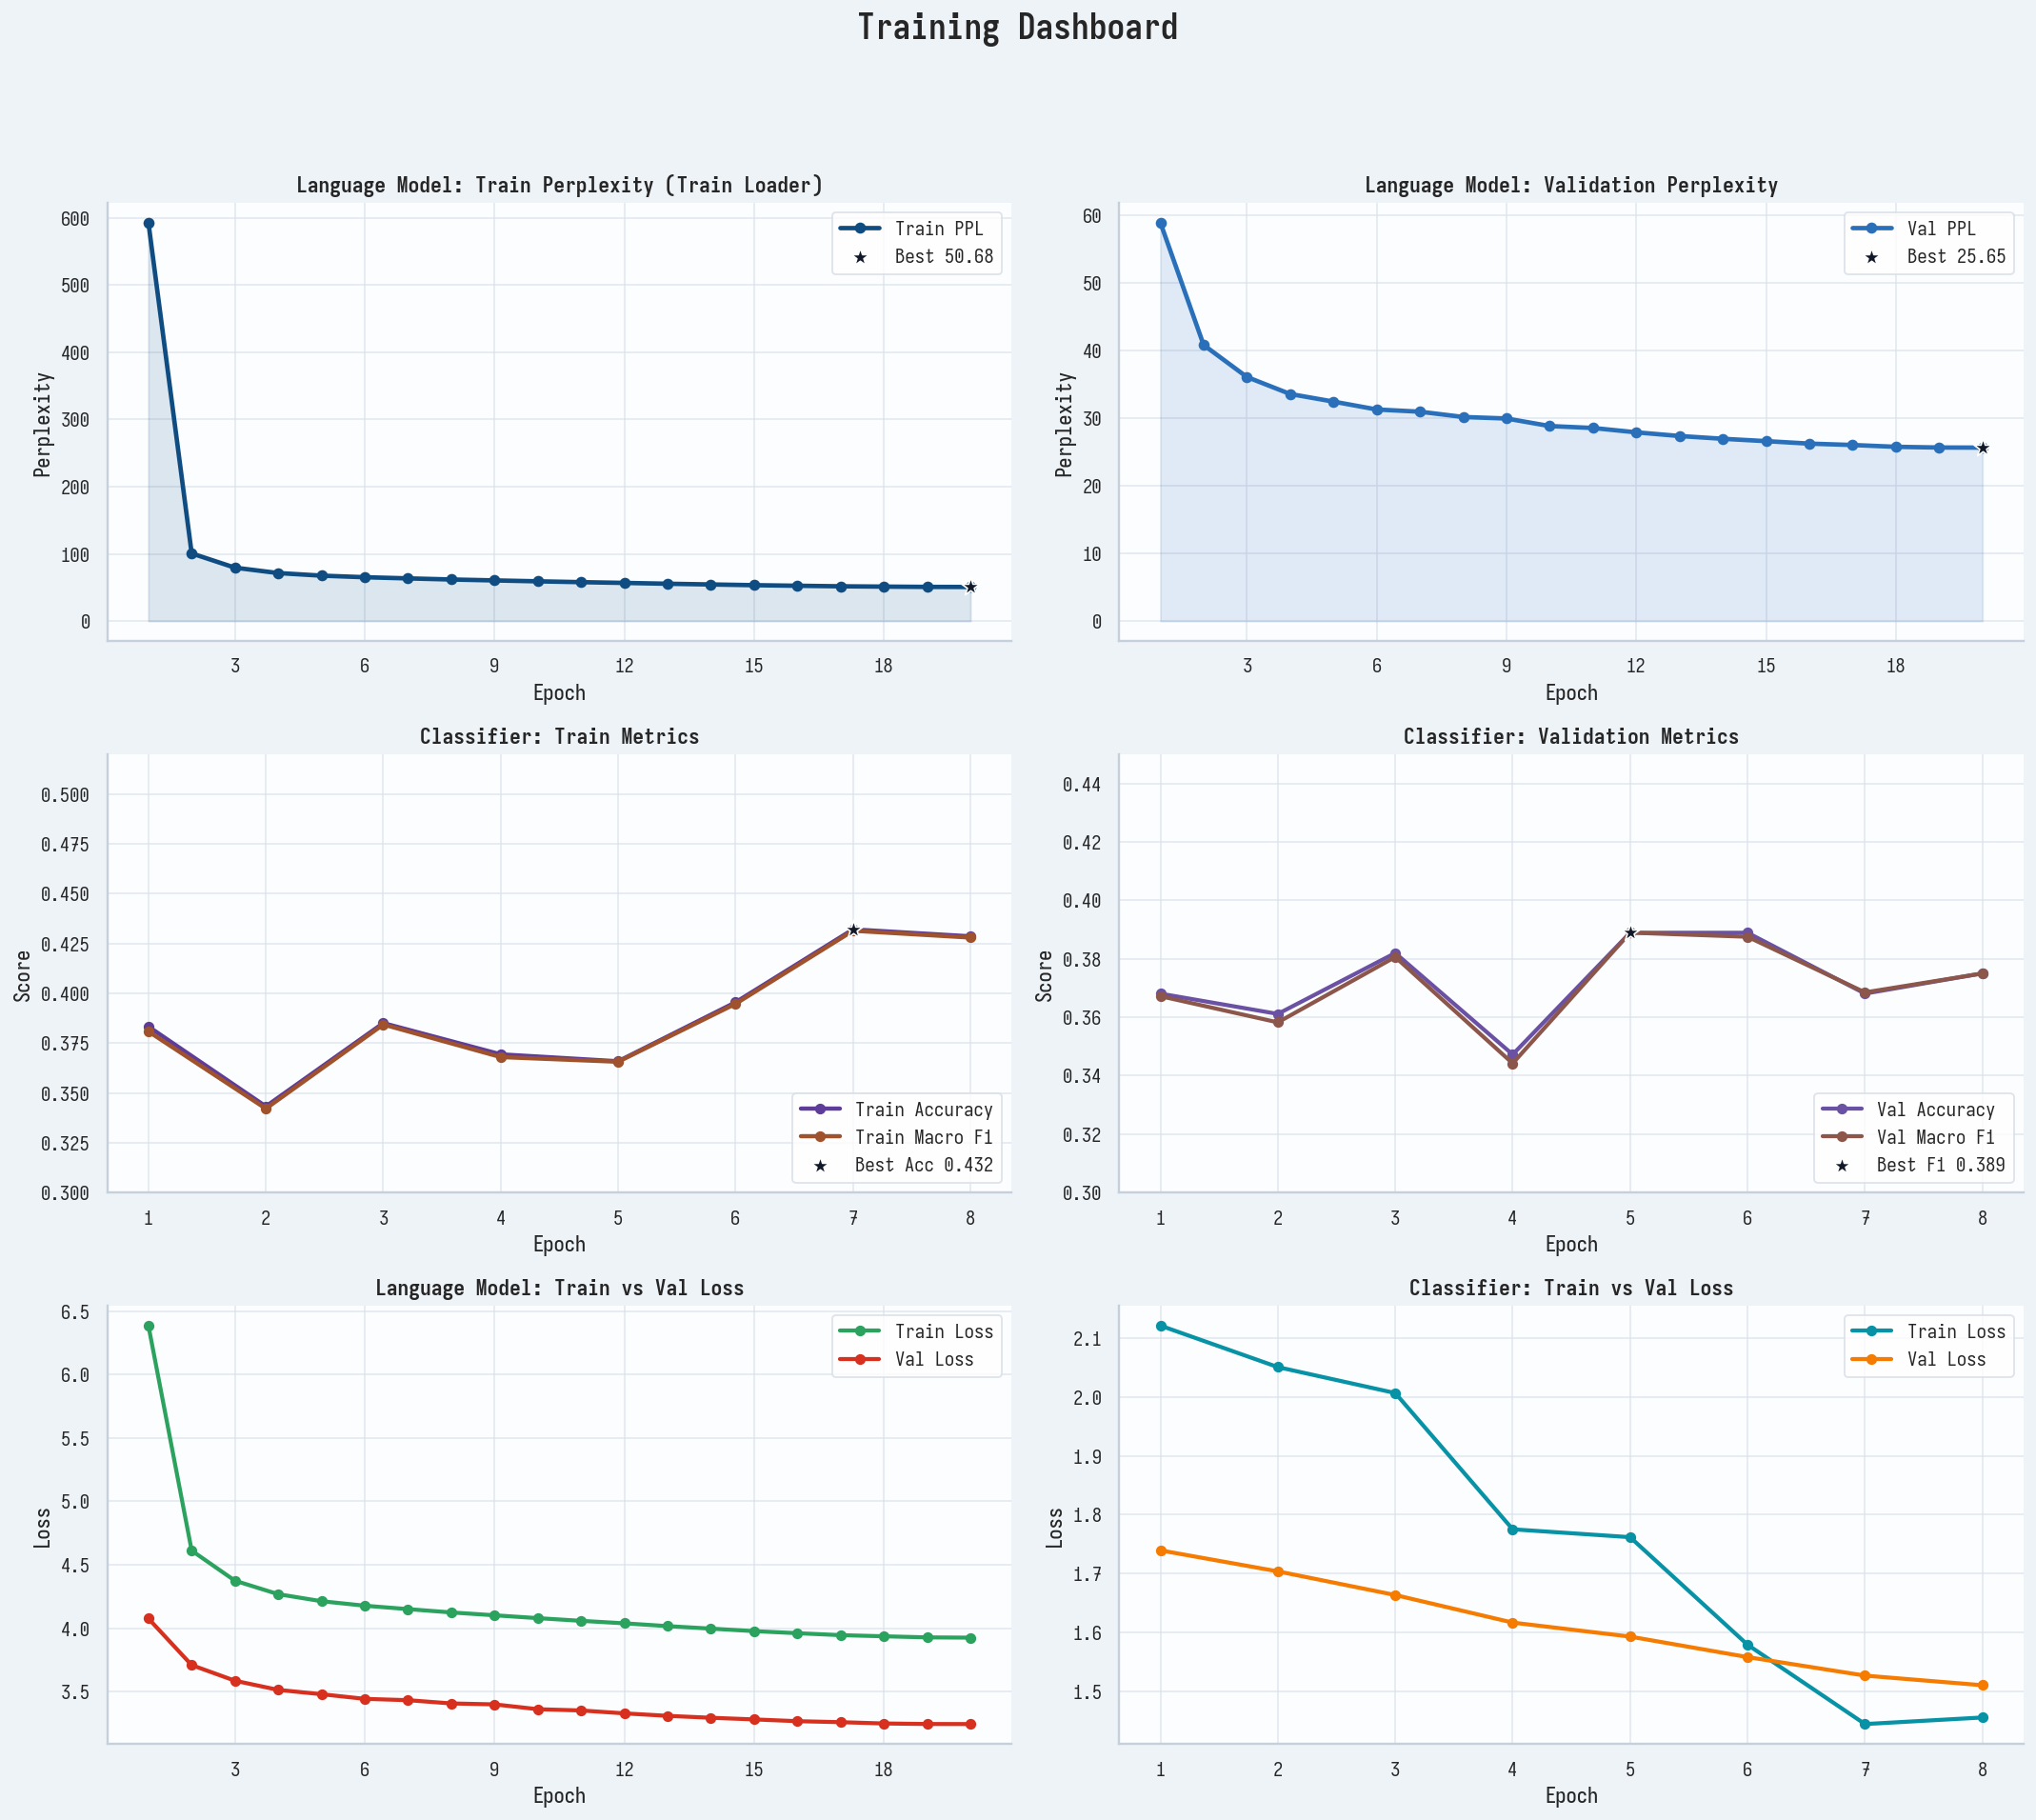

Saved LM log CSV               :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\NLP_assignment_3\outputs\predictions\lm_training_log.csv
Saved CLS log CSV              :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\NLP_assignment_3\outputs\predictions\cls_training_log.csv
Saved summary JSON             :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\NLP_assignment_3\outputs\predictions\training_summary.json
Saved dashboard PNG            :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\NLP_assignment_3\outputs\predictions\training_dashboard.png
Saved dashboard SVG            :  f:\Sayan\Study\Prog\Prog\ML_AI\NLP_assignment_3\NLP_assignment_3\outputs\predictions\training_dashboard.svg


{'best_val_ppl': 25.646365,
 'best_val_acc': 0.388889,
 'best_val_f1': 0.388923,
 'lm_ckpt': 'f:\\Sayan\\Study\\Prog\\Prog\\ML_AI\\NLP_assignment_3\\NLP_assignment_3\\outputs\\checkpoints\\lm_best.pt',
 'cls_ckpt': 'f:\\Sayan\\Study\\Prog\\Prog\\ML_AI\\NLP_assignment_3\\NLP_assignment_3\\outputs\\checkpoints\\classifier_best.pt',
 'generation_file': 'f:\\Sayan\\Study\\Prog\\Prog\\ML_AI\\NLP_assignment_3\\NLP_assignment_3\\outputs\\generations\\generated_hindi.txt',
 'correct_samples_file': 'f:\\Sayan\\Study\\Prog\\Prog\\ML_AI\\NLP_assignment_3\\NLP_assignment_3\\outputs\\predictions\\5_correct_samples.txt',
 'lm_rows': 20,
 'cls_rows': 8}

In [15]:
if "plt" not in globals():
    import matplotlib.pyplot as plt
if "sns" not in globals():
    import seaborn as sns
if "pd" not in globals():
    import pandas as pd
if "Path" not in globals():
    from pathlib import Path
if "os" not in globals():
    import os

import matplotlib.font_manager as fm
from matplotlib.ticker import MaxNLocator

plots_dir = out_dir / "predictions"
plots_dir.mkdir(parents=True, exist_ok=True)

lm_csv = plots_dir / "lm_training_log.csv"
cls_csv_log = plots_dir / "cls_training_log.csv"
summary_json = plots_dir / "training_summary.json"

# Build plotting tables directly from runtime logs when needed.
if "lm_df" not in globals():
    if "lm_log" in globals():
        lm_df = pd.DataFrame(lm_log)
    else:
        raise RuntimeError("LM logs are missing. Run LM training cells first.")

if "cls_df_log" not in globals():
    if "cls_log" in globals():
        cls_df_log = pd.DataFrame(cls_log)
    else:
        raise RuntimeError("Classifier logs are missing. Run classifier training cells first.")

if "best_ppl" not in globals():
    best_ppl = float(lm_df["val_ppl"].min())
if "best_acc" not in globals():
    best_acc = float(cls_df_log["val_acc"].max())
if "best_f1" not in globals():
    best_f1 = float(cls_df_log["val_f1"].max())

if "best_lm_path" not in globals():
    best_lm_path = out_dir / "checkpoints" / "lm_best.pt"
if "best_cls_path" not in globals():
    best_cls_path = out_dir / "checkpoints" / "classifier_best.pt"
if "gen_file" not in globals():
    gen_file = out_dir / "generations" / "generated_hindi.txt"
if "correct_file" not in globals():
    correct_file = out_dir / "predictions" / "5_correct_samples.txt"

lm_df.to_csv(lm_csv, index=False)
cls_df_log.to_csv(cls_csv_log, index=False)

summary_payload = {
    "best_val_ppl": float(best_ppl),
    "best_val_acc": float(best_acc),
    "best_val_f1": float(best_f1),
    "lm_ckpt": str(best_lm_path),
    "cls_ckpt": str(best_cls_path),
    "generation_file": str(gen_file),
    "correct_samples_file": str(correct_file),
    "lm_rows": int(len(lm_df)),
    "cls_rows": int(len(cls_df_log)),
}
pd.Series(summary_payload).to_json(summary_json, indent=2)

font_candidates = ["Iosevka", "Iosevka Term", "Iosevka Fixed"]
font_paths = []

win_font_dir = Path(os.environ.get("WINDIR", "C:/Windows")) / "Fonts"
for pattern in ["Iosevka*.ttf", "iosevka*.ttf", "Iosevka*.otf", "iosevka*.otf"]:
    font_paths.extend(sorted(win_font_dir.glob(pattern)))

local_font_dirs = [Path.cwd() / "fonts", Path.cwd() / "assets" / "fonts", out_dir / "fonts"]
for font_dir in local_font_dirs:
    if font_dir.exists():
        for pattern in ["Iosevka*.ttf", "iosevka*.ttf", "Iosevka*.otf", "iosevka*.otf"]:
            font_paths.extend(sorted(font_dir.glob(pattern)))

for fp in font_paths:
    try:
        fm.fontManager.addfont(str(fp))
    except Exception:
        pass

available_fonts = {f.name for f in fm.fontManager.ttflist}
active_font = next((name for name in font_candidates if name in available_fonts), None)

if active_font is None and font_paths:
    try:
        guessed = fm.FontProperties(fname=str(font_paths[0])).get_name()
        if guessed:
            active_font = guessed
    except Exception:
        pass

if active_font is None:
    active_font = "DejaVu Sans"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.facecolor": "#eef3f8",
        "axes.facecolor": "#fbfdff",
        "font.family": [active_font, "DejaVu Sans"],
        "axes.titleweight": "bold",
        "axes.labelweight": "medium",
        "axes.edgecolor": "#c5d0db",
        "legend.frameon": True,
        "legend.facecolor": "#ffffff",
        "legend.edgecolor": "#d8dee6",
    }
)

colors = {
    "lm_train_ppl": "#0f4c81",
    "lm_val_ppl": "#2a6fba",
    "lm_train_loss": "#2ca25f",
    "lm_val_loss": "#d7301f",
    "cls_train_acc": "#5e3c99",
    "cls_train_f1": "#a0522d",
    "cls_val_acc": "#6a51a3",
    "cls_val_f1": "#8c564b",
    "cls_train_loss": "#0892a5",
    "cls_val_loss": "#f57c00",
    "highlight": "#111827",
}

fig, ax = plt.subplots(3, 2, figsize=(16, 14), dpi=135)
fig.patch.set_facecolor("#eef3f8")

# LM train perplexity (train loader)
ax[0, 0].plot(
    lm_df["epoch"],
    lm_df["train_ppl"],
    marker="o",
    linewidth=2.5,
    markersize=5.2,
    color=colors["lm_train_ppl"],
    label="Train PPL",
)
ax[0, 0].fill_between(lm_df["epoch"], lm_df["train_ppl"], alpha=0.13, color=colors["lm_train_ppl"])
best_lm_train_idx = int(lm_df["train_ppl"].idxmin())
best_lm_train_epoch = int(lm_df.loc[best_lm_train_idx, "epoch"])
best_lm_train_ppl = float(lm_df.loc[best_lm_train_idx, "train_ppl"])
ax[0, 0].scatter(
    [best_lm_train_epoch],
    [best_lm_train_ppl],
    s=115,
    marker="*",
    color=colors["highlight"],
    edgecolor="white",
    linewidth=0.9,
    zorder=5,
    label=f"Best {best_lm_train_ppl:.2f}",
)
ax[0, 0].set_title("Language Model: Train Perplexity (Train Loader)", fontsize=12.5)
ax[0, 0].set_xlabel("Epoch")
ax[0, 0].set_ylabel("Perplexity")
ax[0, 0].legend(loc="upper right")

# LM validation perplexity
ax[0, 1].plot(
    lm_df["epoch"],
    lm_df["val_ppl"],
    marker="o",
    linewidth=2.5,
    markersize=5.2,
    color=colors["lm_val_ppl"],
    label="Val PPL",
)
ax[0, 1].fill_between(lm_df["epoch"], lm_df["val_ppl"], alpha=0.13, color=colors["lm_val_ppl"])
best_lm_idx = int(lm_df["val_ppl"].idxmin())
best_lm_epoch = int(lm_df.loc[best_lm_idx, "epoch"])
best_lm_ppl = float(lm_df.loc[best_lm_idx, "val_ppl"])
ax[0, 1].scatter(
    [best_lm_epoch],
    [best_lm_ppl],
    s=115,
    marker="*",
    color=colors["highlight"],
    edgecolor="white",
    linewidth=0.9,
    zorder=5,
    label=f"Best {best_lm_ppl:.2f}",
)
ax[0, 1].set_title("Language Model: Validation Perplexity", fontsize=12.5)
ax[0, 1].set_xlabel("Epoch")
ax[0, 1].set_ylabel("Perplexity")
ax[0, 1].legend(loc="upper right")

# Classifier train metrics
ax[1, 0].plot(
    cls_df_log["epoch"],
    cls_df_log["train_acc"],
    marker="o",
    linewidth=2.35,
    markersize=5,
    color=colors["cls_train_acc"],
    label="Train Accuracy",
)
ax[1, 0].plot(
    cls_df_log["epoch"],
    cls_df_log["train_f1"],
    marker="o",
    linewidth=2.35,
    markersize=5,
    color=colors["cls_train_f1"],
    label="Train Macro F1",
)
best_cls_train_idx = int(cls_df_log["train_acc"].idxmax())
best_cls_train_epoch = int(cls_df_log.loc[best_cls_train_idx, "epoch"])
best_cls_train_acc = float(cls_df_log.loc[best_cls_train_idx, "train_acc"])
ax[1, 0].scatter(
    [best_cls_train_epoch],
    [best_cls_train_acc],
    s=115,
    marker="*",
    color=colors["highlight"],
    edgecolor="white",
    linewidth=0.9,
    zorder=5,
    label=f"Best Acc {best_cls_train_acc:.3f}",
)
ax[1, 0].set_title("Classifier: Train Metrics", fontsize=12.5)
ax[1, 0].set_xlabel("Epoch")
ax[1, 0].set_ylabel("Score")
ax[1, 0].set_ylim(0.30, max(0.52, float(max(cls_df_log["train_acc"].max(), cls_df_log["train_f1"].max()) + 0.03)))
ax[1, 0].legend(loc="lower right")

# Classifier validation metrics
ax[1, 1].plot(
    cls_df_log["epoch"],
    cls_df_log["val_acc"],
    marker="o",
    linewidth=2.25,
    markersize=5,
    color=colors["cls_val_acc"],
    label="Val Accuracy",
)
ax[1, 1].plot(
    cls_df_log["epoch"],
    cls_df_log["val_f1"],
    marker="o",
    linewidth=2.25,
    markersize=5,
    color=colors["cls_val_f1"],
    label="Val Macro F1",
)
best_cls_idx = int(cls_df_log["val_f1"].idxmax())
best_cls_epoch = int(cls_df_log.loc[best_cls_idx, "epoch"])
best_cls_f1 = float(cls_df_log.loc[best_cls_idx, "val_f1"])
ax[1, 1].scatter(
    [best_cls_epoch],
    [best_cls_f1],
    s=110,
    marker="*",
    color=colors["highlight"],
    edgecolor="white",
    linewidth=0.9,
    zorder=5,
    label=f"Best F1 {best_cls_f1:.3f}",
)
ax[1, 1].set_title("Classifier: Validation Metrics", fontsize=12.5)
ax[1, 1].set_xlabel("Epoch")
ax[1, 1].set_ylabel("Score")
ax[1, 1].set_ylim(0.30, max(0.45, float(max(cls_df_log["val_acc"].max(), cls_df_log["val_f1"].max()) + 0.02)))
ax[1, 1].legend(loc="lower right")

# LM train/val loss
ax[2, 0].plot(
    lm_df["epoch"],
    lm_df["train_loss"],
    marker="o",
    linewidth=2.25,
    markersize=5,
    color=colors["lm_train_loss"],
    label="Train Loss",
)
ax[2, 0].plot(
    lm_df["epoch"],
    lm_df["val_loss"],
    marker="o",
    linewidth=2.25,
    markersize=5,
    color=colors["lm_val_loss"],
    label="Val Loss",
)
ax[2, 0].set_title("Language Model: Train vs Val Loss", fontsize=12.5)
ax[2, 0].set_xlabel("Epoch")
ax[2, 0].set_ylabel("Loss")
ax[2, 0].legend(loc="upper right")

# Classifier train/val loss
ax[2, 1].plot(
    cls_df_log["epoch"],
    cls_df_log["train_loss"],
    marker="o",
    linewidth=2.25,
    markersize=5,
    color=colors["cls_train_loss"],
    label="Train Loss",
)
ax[2, 1].plot(
    cls_df_log["epoch"],
    cls_df_log["val_loss"],
    marker="o",
    linewidth=2.25,
    markersize=5,
    color=colors["cls_val_loss"],
    label="Val Loss",
)
ax[2, 1].set_title("Classifier: Train vs Val Loss", fontsize=12.5)
ax[2, 1].set_xlabel("Epoch")
ax[2, 1].set_ylabel("Loss")
ax[2, 1].legend(loc="upper right")

for a in ax.flatten():
    a.xaxis.set_major_locator(MaxNLocator(integer=True))
    a.grid(True, color="#dce2eb", alpha=0.8, linewidth=0.85)
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

plt.suptitle("Training Dashboard", fontsize=20, weight="bold", y=1.01)
plt.tight_layout(rect=(0.0, 0.0, 1.0, 0.965))

dash_png = plots_dir / "training_dashboard.png"
dash_svg = plots_dir / "training_dashboard.svg"
fig.savefig(dash_png, bbox_inches="tight", facecolor=fig.get_facecolor())
fig.savefig(dash_svg, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Saved LM log CSV               : ", lm_csv)
print("Saved CLS log CSV              : ", cls_csv_log)
print("Saved summary JSON             : ", summary_json)
print("Saved dashboard PNG            : ", dash_png)
print("Saved dashboard SVG            : ", dash_svg)

summary = summary_payload
summary